Using torch vison dataset to train a nn model

In [223]:
from torch.utils.data import DataLoader
from torchvision import datasets
from torchvision.transforms import ToTensor
import torch

train_data = datasets.FashionMNIST(
    root="",
    train=True,
    transform=ToTensor(),
    download=True
)
test_data = datasets.FashionMNIST(
    root="",
    train=False,
    transform=ToTensor(),
    download=True
)

100.0%
100.0%
100.0%
100.0%


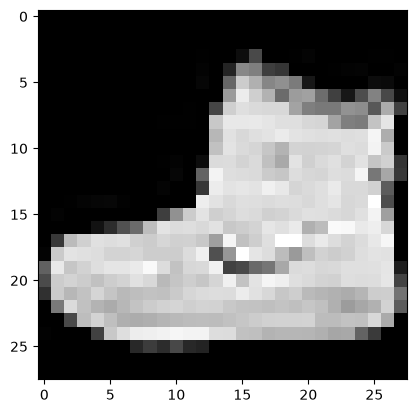

In [212]:
import matplotlib.pyplot as plt

img, label = train_data[0]
plt.imshow(img.squeeze(), cmap="gray")

In [213]:
BATCH_SIZE = 32
train_dataloader = DataLoader(
    dataset=train_data,
    batch_size=BATCH_SIZE,
    shuffle=True
)
test_dataloader = DataLoader(
    dataset=test_data,
    batch_size=BATCH_SIZE,
    shuffle=False
)

len(train_dataloader)

1875

In [214]:
classes = train_data.classes
classes

['T-shirt/top',
 'Trouser',
 'Pullover',
 'Dress',
 'Coat',
 'Sandal',
 'Shirt',
 'Sneaker',
 'Bag',
 'Ankle boot']

In [215]:
X, y = next(iter(train_dataloader))

In [216]:
y[0]

tensor(0)

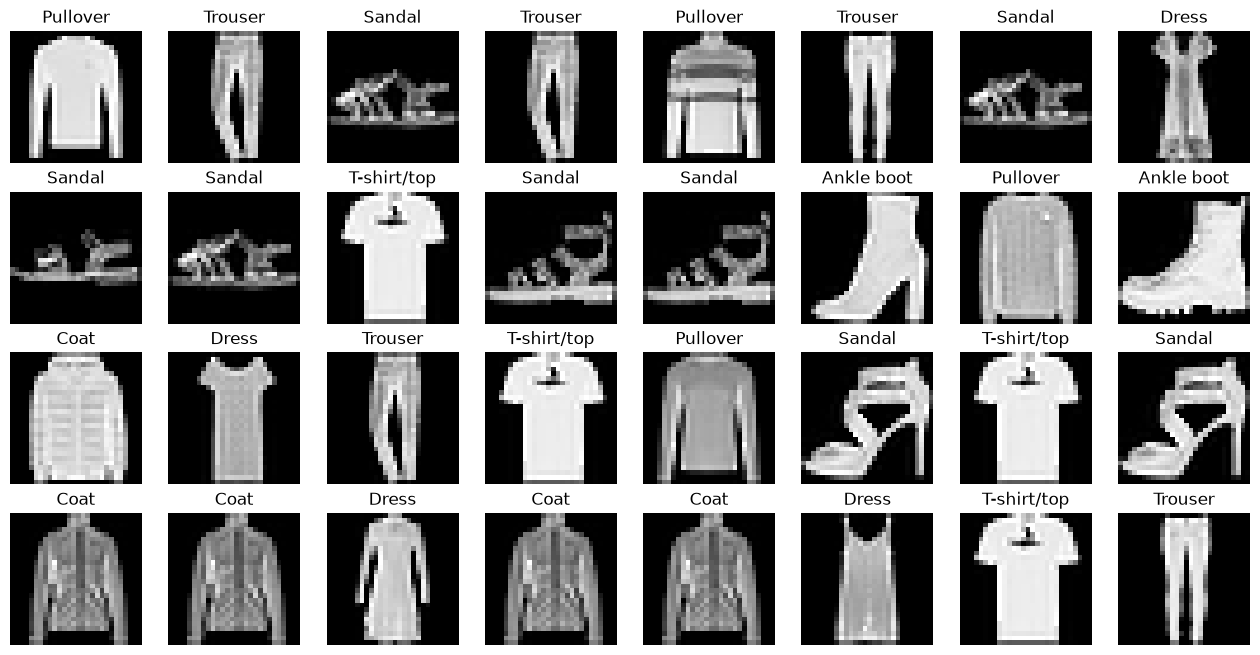

In [217]:
rows, cols = 4, 8
fig = plt.figure(figsize=(16,8))
for i in range(1,rows*cols+1):
    fig.add_subplot(rows,cols,i)
    idx = torch.randint(low=0,high=len(y),size=[1]).item()
    img, label = X[idx].squeeze(),y[idx].item()
    plt.imshow(img, cmap="gray")
    plt.axis(False)
    plt.title(classes[label])

In [218]:
from torch import nn
class Fashion(nn.Module):
    def __init__(self, in_:int, out:int, hidden:int):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Flatten(),
            nn.Linear(in_features=in_, out_features=hidden),
            nn.ReLU(),
            nn.Linear(in_features=hidden, out_features=out)
        )
        
    def forward(self, x):
        return self.layers(x)
    
    
model = Fashion(
    in_=(28*28),
    out=len(classes),
    hidden=10
)
model

Fashion(
  (layers): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=10, bias=True)
    (2): ReLU()
    (3): Linear(in_features=10, out_features=10, bias=True)
  )
)

In [219]:
from sklearn.metrics import accuracy_score

loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(
    params=model.parameters(),
    lr=0.1
)
loss_fn

CrossEntropyLoss()

In [220]:
device = "cuda" if torch.cuda.is_available else "cpu"
device

'cuda'

In [221]:
from tqdm.auto import tqdm
def train_model(
    model : torch.nn.Module,
    data_loader : torch.utils.data.DataLoader,
    loss_fn : torch.nn.Module,
    optimizer : torch.optim.Optimizer,
    acc_fn,
    device : torch.device = device
):
    model = model.to(device)
    model.train()
    train_acc, train_loss = 0, 0
    for batch, (X, y) in tqdm(enumerate(data_loader)):
        X = X.float().to(device)
        y = y.long().to(device)
        optimizer.zero_grad()
        y_logits = model(X)
        y_preds = y_logits.argmax(dim=1)
        loss = loss_fn(y_logits,y)
        train_loss += loss
        train_acc += acc_fn(y.cpu(),y_preds.cpu())
        loss.backward()
        optimizer.step()
    train_acc /= len(data_loader)
    train_loss /= len(data_loader)
    print(f"train loss : {train_loss:.4f} | train acc : {train_acc:.2f}")
    
    
def test_model(
    model : torch.nn.Module,
    loss_fn : torch.nn.Module,
    acc_fn,
    data_loader : torch.utils.data.DataLoader,
    device: torch.device = device,
):
    model = model.to(device)
    model.eval()
    test_loss, test_acc = 0, 0
    with torch.inference_mode():
        for X, y in tqdm(data_loader):
            X = X.float().to(device)
            y = y.long().to(device)
            y_logits = model(X)
            y_preds = y_logits.argmax(dim=1)
            loss = loss_fn(y_logits,y)
            test_loss += loss
            test_acc += acc_fn(y.cpu(), y_preds.cpu())
        test_acc /= len(data_loader)
        test_loss /= len(data_loader)
        print(f"test loss : {test_loss:.4f} | test acc : {test_acc:.2f}")

In [222]:
from timeit import default_timer as timer
st = timer()
epochs = 3

for epoch in tqdm(range(epochs)):
    print(f"Epoch : {epoch}\n---------")
    train_model(
        model=model,
        data_loader=train_dataloader,
        loss_fn=loss_fn,
        optimizer=optimizer,
        acc_fn=accuracy_score
    )
    test_model(
        model=model,
        loss_fn=loss_fn,
        acc_fn=accuracy_score,
        data_loader=test_dataloader
    )
end = timer()

print(f"time of execution : {end - st}")

  0%|          | 0/3 [00:00<?, ?it/s]

Epoch : 0
---------


0it [00:00, ?it/s]

train loss : 0.6355 | train acc : 0.77


  0%|          | 0/313 [00:00<?, ?it/s]

...

test loss : 0.5041 | test acc : 0.82
Epoch : 2
---------


0it [00:00, ?it/s]

train loss : 0.4596 | train acc : 0.84


  0%|          | 0/313 [00:00<?, ?it/s]

test loss : 0.4962 | test acc : 0.83
time of execution : 24.433869642998616
